In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv('realistic_height_weight_scattered.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,48,123
2,50,129
3,52,124
4,55,140


Text(0, 0.5, 'Height')

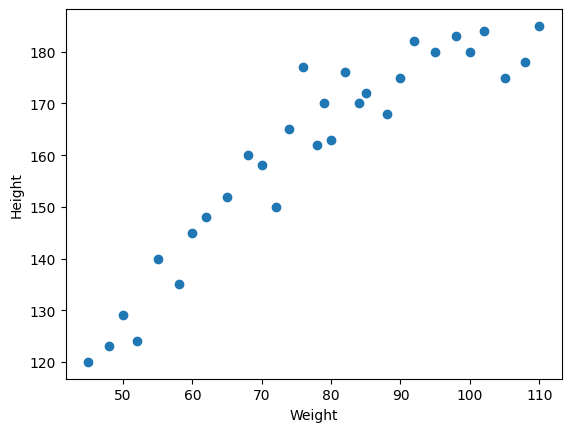

In [4]:
##scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [5]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.930801
Height,0.930801,1.000000


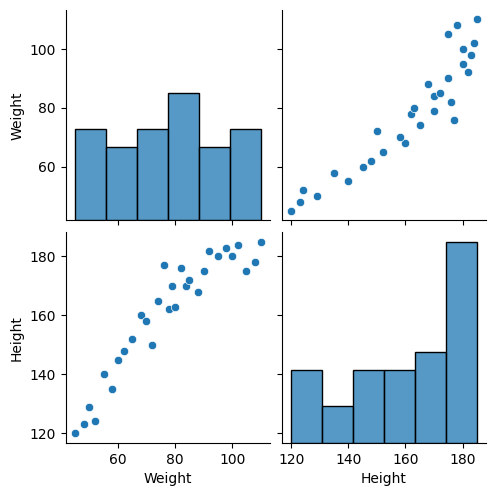

In [6]:
## Seaborn for Visualization
import seaborn as sns
sns.pairplot(df)

In [7]:
## Independent and dependent features
X = df[['Weight']]  ### independent feature should be data frame or 2 dimension array
y =df['Height'] ## this variable can be in series or 1d array

In [8]:
X_series = df['Weight']
np.array(X_series).shape

(30,)

In [9]:
np.array(y).shape

(30,)

In [10]:
y

0     120
1     123
2     129
3     124
4     140
5     135
6     145
7     148
8     152
9     160
10    158
11    150
12    165
13    177
14    162
15    170
16    163
17    176
18    170
19    172
20    168
21    175
22    182
23    180
24    183
25    180
26    184
27    175
28    178
29    185
Name: Height, dtype: int64

In [11]:
## Train Test Split
from sklearn.model_selection import train_test_split


In [12]:
X_train,X_test,y_train,Y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [13]:
## Standardization

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)

In [16]:
X_test = scalar.transform(X_test)

In [17]:
X_test

array([[ 1.68710883],
       [ 0.26586251],
       [ 1.14047563],
       [ 0.42985247],
       [-0.49942397],
       [-0.33543401],
       [ 1.85109879],
       [ 1.30446559]])

In [18]:
## Apply Simple linear Regresssion
from sklearn.linear_model import LinearRegression

In [19]:
regression = LinearRegression(n_jobs=-1)

In [20]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
print("coefficient or slope:",regression.coef_) #<---slope
print("intercept::",regression.intercept_) 

coefficient or slope: [19.78032893]
intercept:: 157.04545454545453


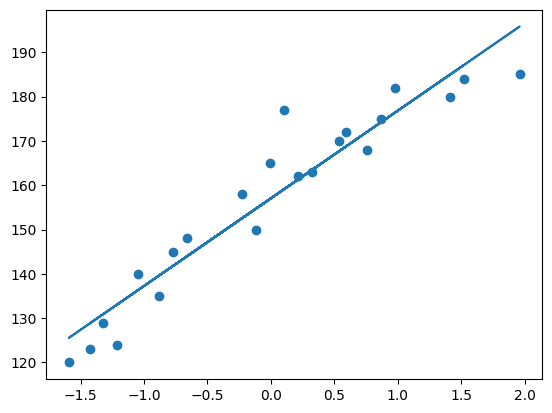

In [22]:
## plot training data plot beat fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

### Prediction of Test Data

1. Predicted Height Output = Intercept + Coef_(Weights)

2. y_pred_test = 157.045 + 19.78(X_test)

In [23]:
## Prediction for test data
y_pred = regression.predict(X_test)

In [24]:
## performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [25]:
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

95.8639159034562
8.024455632589824
9.791011995879497


# R Square

## Formula

R² = 1 - (SSR / SST)

R² = Coefficient of Determination

SSR = Sum of Squares of Residuals

SST = Total Sum of Squares

In [26]:
from sklearn.metrics import r2_score

In [27]:
score = r2_score(Y_test,y_pred)
print(score)

0.03350809423106538


# Adjusted R²

## Formula

Adjusted R² = 1 - [((1 - R²) * (n - 1)) / (n - k - 1)]

### Where:

- **R²** = R Square (Coefficient of Determination)
- **n** = Number of Observations
- **k** = Number of Predictor Variables (Independent Features)

In [28]:
# Display Adjusted R-Squared

1 - (1 - score) * ((len(Y_test) - 1) / (len(Y_test) - X_test.shape[1] - 1))

-0.12757389006375708

In [29]:
## OLS Linear Regression
import statsmodels.api as sm

In [30]:
model = sm.OLS(y_train,X_train).fit()

In [31]:
prediction = model.predict(X_test)
print(prediction)

[33.37156762  5.25884792 22.55898312  8.50262327 -9.87877039 -6.63499504
 36.61534298 25.80275847]


In [32]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.016
Model:                            OLS   Adj. R-squared (uncentered):             -0.031
Method:                 Least Squares   F-statistic:                             0.3326
Date:                Sun, 28 Jun 2026   Prob (F-statistic):                       0.570
Time:                        00:16:19   Log-Likelihood:                         -142.48
No. Observations:                  22   AIC:                                      287.0
Df Residuals:                      21   BIC:                                      288.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [33]:
## Prediction for new data
regression.predict(scalar.transform([[72]]))

C:\Users\ARNAV MAHAJAN\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([154.73549331])